# Flight_Fare_Prediction

## Summary

In this project, flight fare data was analyzed to understand the factors that
influence flight prices. Data preprocessing and exploratory data analysis were
performed to prepare the dataset for machine learning.

Five regression models were developed and compared: Linear Regression, Decision
Tree, Random Forest, Gradient Boosting, and KNN. Random Forest performed the
best among the initial models. Hyperparameter tuning was then performed to
further improve its performance.

The tuned Random Forest model achieved an R² Score of 0.8280, with an MAE of
1177.72 and an RMSE of 1893.62. Based on these results, the tuned Random Forest
was selected as the final model for flight price prediction.

The model can help customers estimate flight fares and make better decisions
while planning their journeys.

In [1]:
!pip install openpyxl

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np

# Data visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load feature values
df=pd.read_excel("Flight_Fare.xlsx")

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.shape

(10683, 11)

### Data Understanding

The dataset contains flight-related information such as airline, journey date,
source, destination, route, departure time, arrival time, duration, number of
stops, additional information, and flight price. The target variable for this
project is Price, which is a continuous numerical variable.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


###### The maximum price is 79512, while the median is 8372 rupees
###### That suggests that there may be outliers or some unusually expensive flights.
###### These should be investigate during EDA.

###### In this Dataset price is contineous numerical data,
###### Hence this is a regression problem 

###  Data Cleaning

The dataset was checked for duplicate and missing values. Duplicate records
were removed, and rows with missing Route and Total_Stops values were removed
to avoid problems during model building. After cleaning, the dataset was
checked again to make sure the required values were available.

In [7]:
df.duplicated().sum()

np.int64(220)

In [8]:
print("Before removing duplictes:",df.shape)
print("Duplicate rows:",df.duplicated().sum())

Before removing duplictes: (10683, 11)
Duplicate rows: 220


In [9]:
df=df.drop_duplicates()

In [10]:
print("After removing duplicates:",df.shape)
print("Duplicate rows:",df.duplicated().sum())

After removing duplicates: (10463, 11)
Duplicate rows: 0


In [11]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [12]:
df[df['Route'].isnull() | df['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [13]:
df=df.dropna(subset=['Route','Total_Stops'])

In [14]:
print(df.isnull().sum())
print(df.shape)

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
(10462, 11)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.8+ KB


### Check Unique Values

###### This is important to understand the categories in each column

### Unique Values

The unique values in each column were checked to understand the different
categories present in the dataset. This helped in identifying categorical
features such as Airline, Source, and Destination and deciding how they should
be handled during preprocessing.

In [16]:
print(df.nunique())


Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64


### Exploratory Data Analysis

In [17]:
print("Airlines:")
print(df['Airline'].value_counts())

print("\nsource:")
print(df['Source'].value_counts())

print("\nDestination:")
print(df['Destination'].value_counts())

print("\nTotal_Stops:")
print(df['Total_Stops'].value_counts())

print("Additional Info:")
print(df['Additional_Info'].value_counts())

Airlines:
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

source:
Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

Destination:
Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

Total_Stops:
Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64
Additional Info:
Additional_

###### We can observe
###### Airline: Jet Airways has the highest number of flights, followed by IndiGo and Air India.
###### Source: Delhi is the most common departure location.
###### Destination: Cochin is the most common destination.
###### Total Stops: Most flights have 1 stop (5,625), followed by non-stop flights (3,475).
###### Additional_Info: "No info" dominates with 8,182 records. This variable may not add much predictive value and we can evaluate it later.

#### 1 Checking Price Distribusion

###### Since Price is our target variable, let's visualize its distribution.

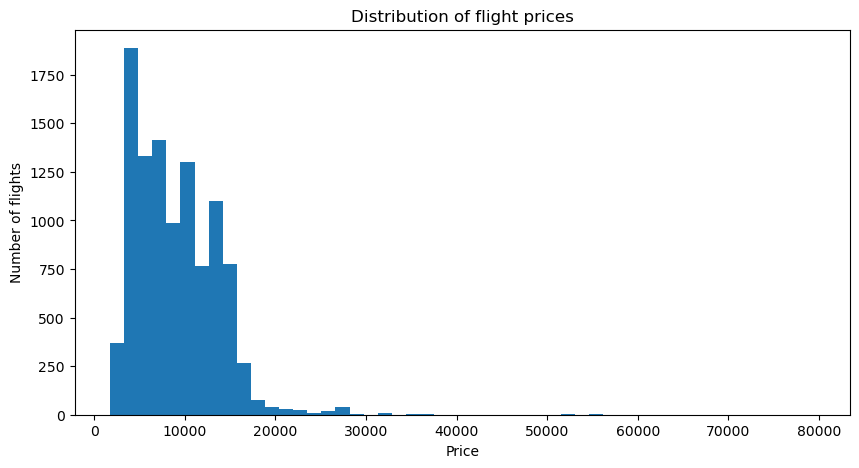

In [18]:
plt.figure(figsize=(10,5))
plt.hist(df['Price'],bins=50)
plt.xlabel('Price')
plt.ylabel('Number of flights')
plt.title('Distribution of flight prices')
plt.show()

##### Conclusion-
###### Most flight prices are between roughly ₹3,000 and ₹15,000.
###### The distribution is right-skewed — most observations are on the lower-price side, with a smaller number of flights having very high prices.
###### There are some high-price outliers, extending up to around ₹80,000.
###### This is important because extreme prices can affect regression models.

###### We should not remove these high-price values just because they are potential high_price outliers. They may represent genuine expensive flights.


#### Airline vs Price plot

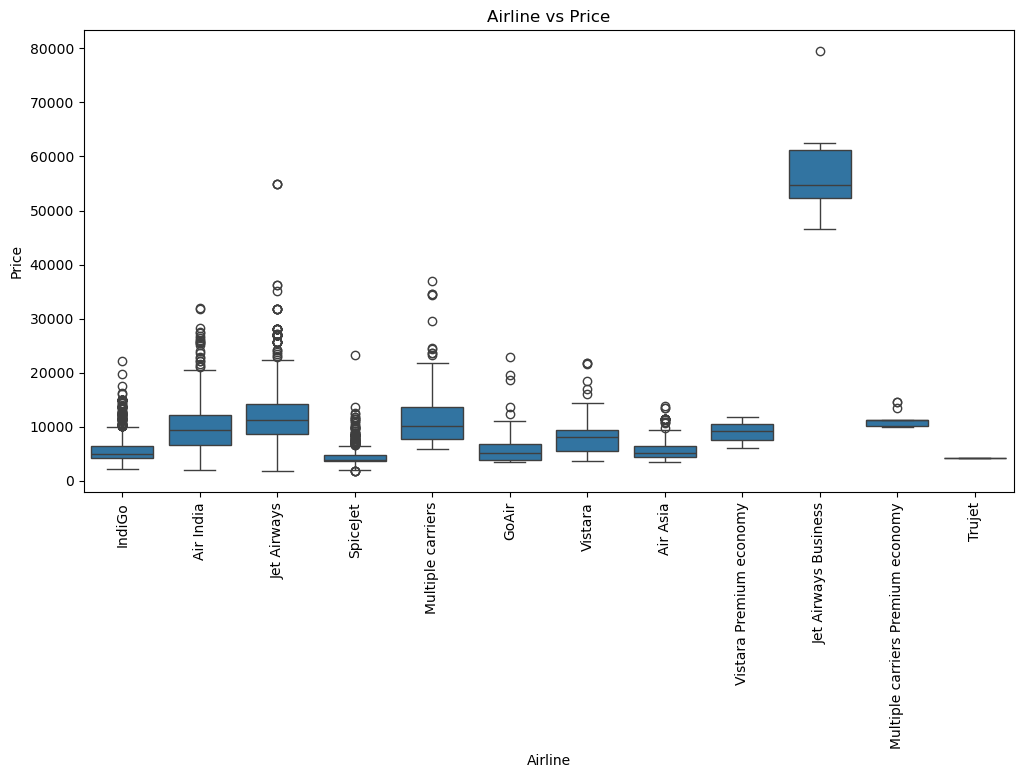

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline',y='Price',data=df)
plt.xticks(rotation=90)
plt.title('Airline vs Price')
plt.show()

##### Conclusion-
###### Jet Airways Business has the highest prices, with fares reaching around ₹80,000. However, there are very few observations.
###### Multiple carriers and Air India also show relatively higher price ranges.
###### IndiGo, SpiceJet, GoAir and Air Asia generally have lower fare ranges.
###### Most airlines have several high-price outliers, indicating that some flights are much more expensive than the typical fare for that airline.
###### Trujet and premium/business categories have very few observations, so their price patterns should be interpreted cautiously.


#### Source vs Price plot

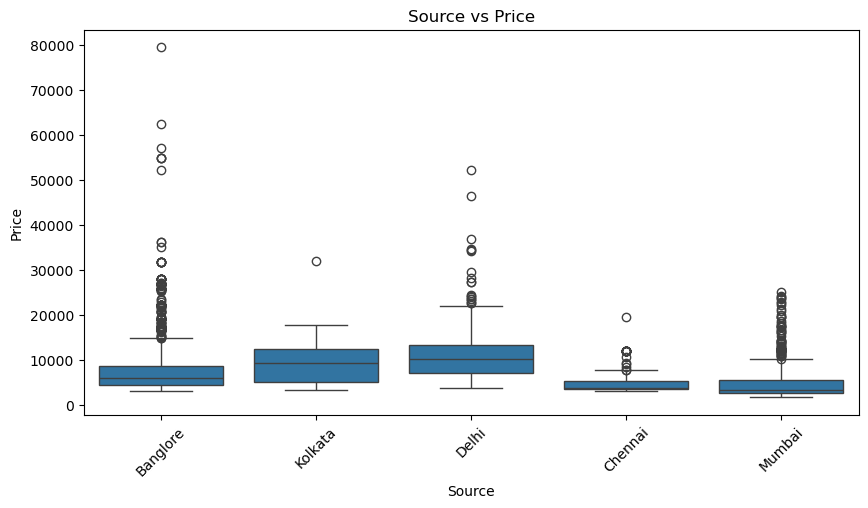

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Source',y='Price',data=df)
plt.xlabel('Source')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Source vs Price')
plt.show()


### Summary – Unique Values

The unique values in each column were checked to understand the different
categories present in the dataset. This helped in identifying categorical
features such as Airline, Source, and Destination and deciding how they should
be handled during preprocessing.

##### conclusion-
###### Delhi has the highest median flight price among the sources.
###### Kolkata also shows relatively higher prices compared with Bangalore, Chennai, and Mumbai.
###### Bangalore has a moderate median price but contains many high-price outliers.
###### Chennai and Mumbai generally have lower median flight prices.
###### All sources show some high-price outliers, especially Bangalore and Delhi.
###### Therefore, Source appears to have an influence on flight price, with the typical price varying across different departure cities.
###### Several high-price outliers are present across the sources, indicating that some flights are considerably more expensive than the typical fare.

#### Destination vs Price plot

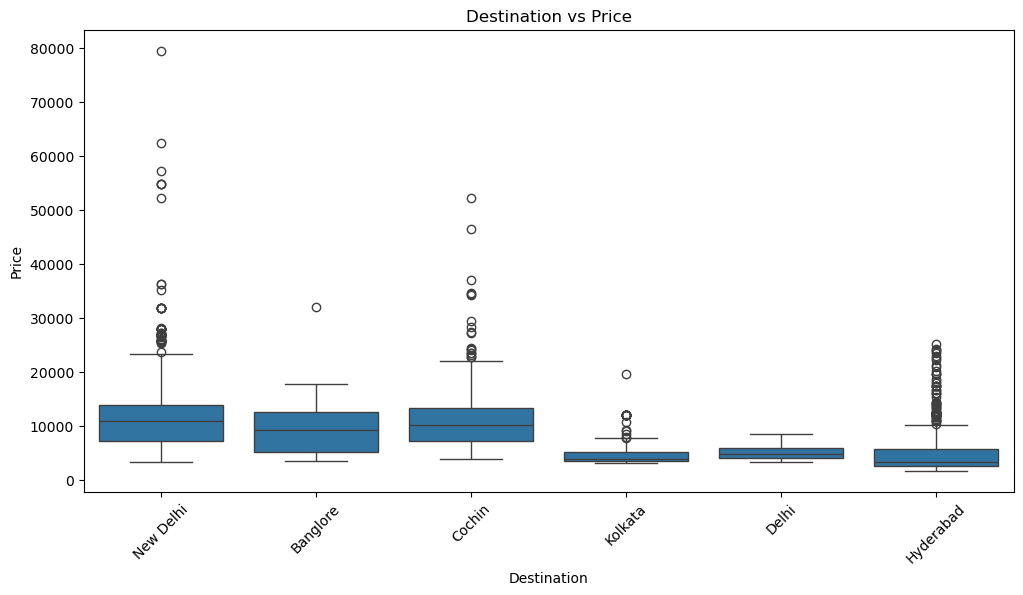

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Destination',y='Price',data=df)
plt.xlabel('Destination')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Destination vs Price')
plt.show()


###### Conclusion-
###### New Delhi has one of the highest median flight prices among the destinations.
###### Cochin also shows relatively high median prices and a wide price spread.
###### Bangalore has a moderate-to-high median price.
###### Kolkata, Delhi, and Hyderabad generally have lower median prices compared with New Delhi and Cochin.
###### New Delhi and Cochin have several high-price outliers, with New Delhi reaching close to ₹80,000.
###### Hyderabad also has many outliers, although most fares are concentrated at the lower end.
###### Overall, destination appears to influence flight prices, but there is considerable variation within each destination.

######  Flight prices vary across different destinations.
###### New Delhi and Cochin generally have higher median fares, 
###### while Kolkata, Delhi, and Hyderabad have comparatively lower median prices. 
###### Several high-price outliers are observed, particularly for New Delhi and Cochin. 
###### This suggests that Destination may be an important feature for predicting flight prices.

#### Total_Stops vs Price

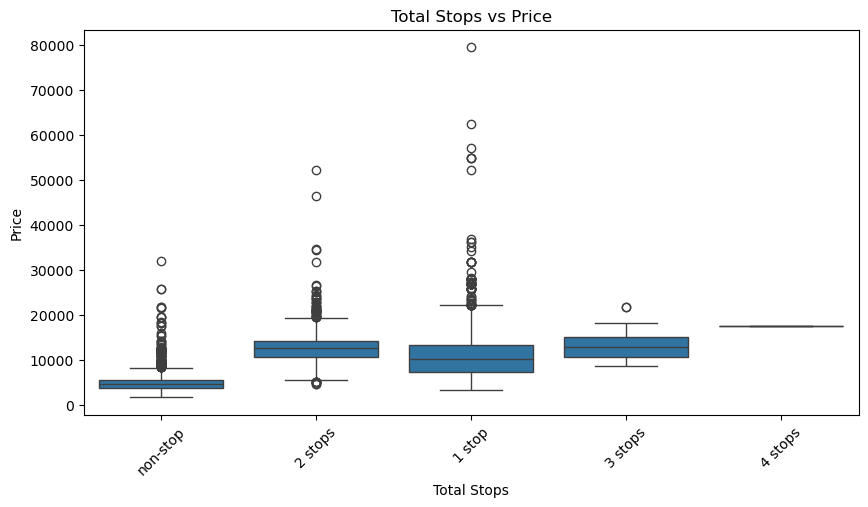

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.title('Total Stops vs Price')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

###### Conclusion-
###### Non-stop flights generally have the lowest median price.
###### 2-stop flights have a higher median price than non-stop flights and show considerable variation.
###### 1-stop flights have a moderate median price but show the largest spread and many high-price outliers, including values close to ₹80,000.
###### 3-stop flights have a relatively high median price, but there are very few observations.
###### 4-stop flights show a high price, but there appears to be only a very small number of observations, so we should not draw a strong conclusion from this category.
###### Overall, Total_Stops appears to have a relationship with flight price, but the relationship is not simply "more stops = higher price." Other factors such as airline, source, destination, duration, and route also influence the fare.

###### Flight prices vary across different numbers of stops.
###### Non-stop flights generally have lower median prices, while 2-stop and 3-stop flights show relatively higher median prices. 
###### One-stop flights have a wide price range with several high-price outliers. 
###### However, the relationship is not strictly linear, and categories with very few observations should be interpreted cautiously. 
###### Therefore, Total_Stops is likely to be an important feature for flight price prediction.

#### Additional_info vs Price

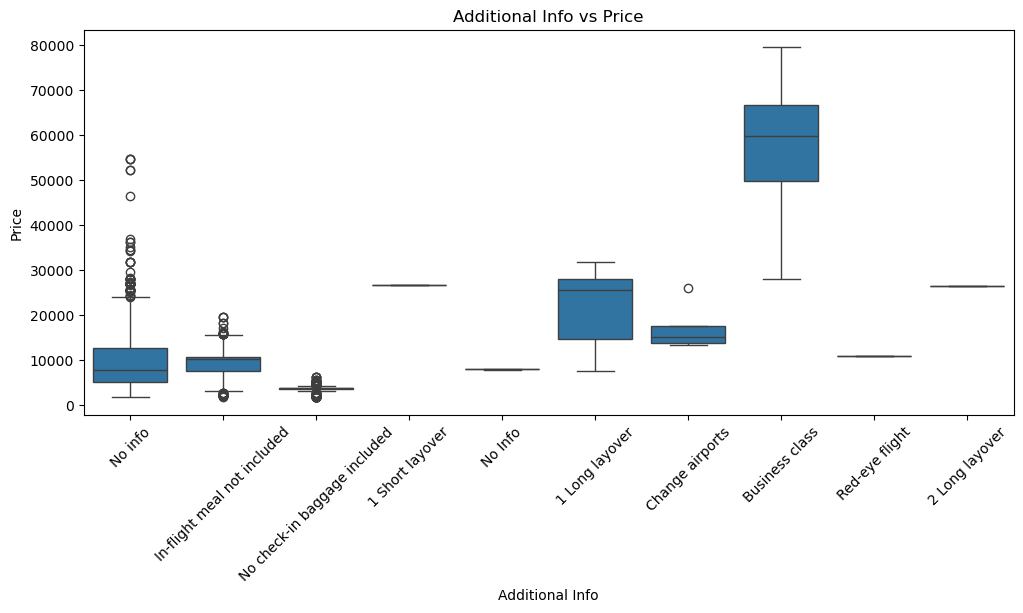

In [23]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Additional_Info', y='Price', data=df)
plt.title('Additional Info vs Price')
plt.xlabel('Additional Info')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

### Numerical EDA

#### Check Date_of_Journey

In [24]:
print(df['Date_of_Journey'].value_counts().sort_index())

Date_of_Journey
01/03/2019    151
03/03/2019     92
06/03/2019     95
09/03/2019    100
1/03/2019      47
1/04/2019     256
1/05/2019     274
1/06/2019     330
12/03/2019    141
12/04/2019     63
12/05/2019    259
12/06/2019    483
15/03/2019    162
15/04/2019     89
15/05/2019    402
15/06/2019    314
18/03/2019    156
18/04/2019     67
18/05/2019    486
18/06/2019    105
21/03/2019    412
21/04/2019     82
21/05/2019    482
21/06/2019    109
24/03/2019    314
24/04/2019     92
24/05/2019    286
24/06/2019    330
27/03/2019    290
27/04/2019     94
27/05/2019    369
27/06/2019    339
3/03/2019     217
3/04/2019     110
3/05/2019      90
3/06/2019     326
6/03/2019     302
6/04/2019     100
6/05/2019     281
6/06/2019     490
9/03/2019     199
9/04/2019     125
9/05/2019     466
9/06/2019     485
Name: count, dtype: int64


In [25]:
print(df['Date_of_Journey'].min())
print(df['Date_of_Journey'].max())

01/03/2019
9/06/2019


##### conclusion-
###### The dataset contains journey dates from 1 March 2019 to 24 June 2019.
###### The number of flights varies significantly across dates.
###### Some dates have relatively high observations, for example:
###### 12/06/2019 → 483
###### 18/05/2019 → 486
###### 21/05/2019 → 482
###### 06/06/2019 → 490
###### 09/06/2019 → 485
###### Some dates have considerably fewer observations, such as 03/05/2019 = 90 and 21/04/2019 = 82.
###### Notice that dates appear in formats such as 01/03/2019 and 1/03/2019.
###### We'll standardize the date format during preprocessing.

In [26]:
print(df['Dep_Time'].value_counts().head(20))

Dep_Time
18:55    233
17:00    227
07:05    202
07:10    201
10:00    196
20:00    185
09:00    184
09:35    181
21:10    179
07:00    167
13:00    164
14:05    163
11:40    161
10:20    159
11:30    157
08:00    152
06:30    140
09:45    139
08:25    136
06:00    130
Name: count, dtype: int64


##### Conclusion-
###### 18:55 is the most frequent departure time with 233 flights.
###### 17:00 follows with 227 flights.
###### Morning departure times such as 07:05, 07:10, 09:00, etc. are also quite common.
###### There is a good spread of departure times across the day.
###### Since there are many unique time values, using every individual time as a category would not be ideal for modeling.
###### Later, we can extract hour and minute from Dep_Time, and the hour can be used as a useful numerical feature

#### DEP_Hour Plot
###### Instead of plotting hundreds of individual times, let's first extract the departure hour.

###### Creating Dep_Hour here is technically feature engineering, not just EDA but is created to understand the departure-time pattern

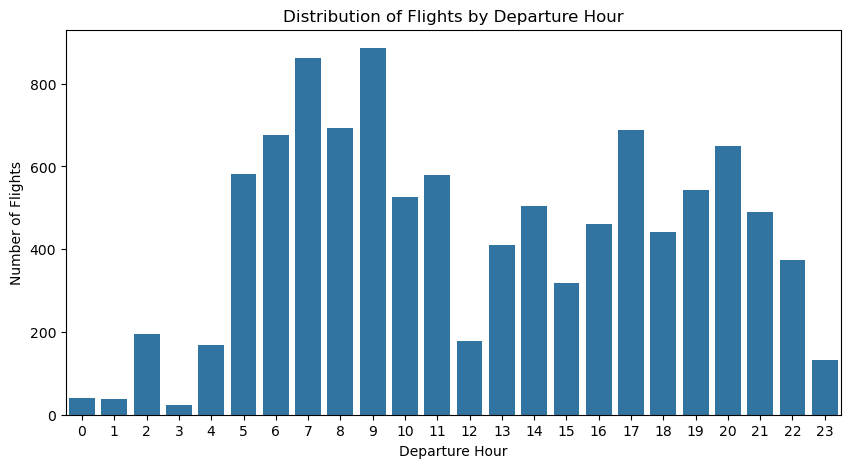

In [27]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
plt.figure(figsize=(10,5))
sns.countplot(x='Dep_Hour', data=df)
plt.title('Distribution of Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.show()

In [28]:
print(df['Dep_Hour'].value_counts().sort_index())

Dep_Hour
0      40
1      37
2     194
3      24
4     169
5     582
6     675
7     863
8     694
9     886
10    527
11    579
12    178
13    411
14    505
15    319
16    461
17    689
18    441
19    544
20    649
21    489
22    373
23    133
Name: count, dtype: int64


##### Conclusion-
###### 9 AM has the highest number of flights: 886.
###### 7 AM is also very common: 863.
###### 6 AM has 675 flights.
###### Evening departures are also significant, especially 5 PM (689) and 8 PM (649).
###### Very early morning hours such as 1 AM (37) and 3 AM (24) have very few flights.
###### Therefore, departure times are not evenly distributed throughout the day

#### Distribusion of flights by Departure Hour

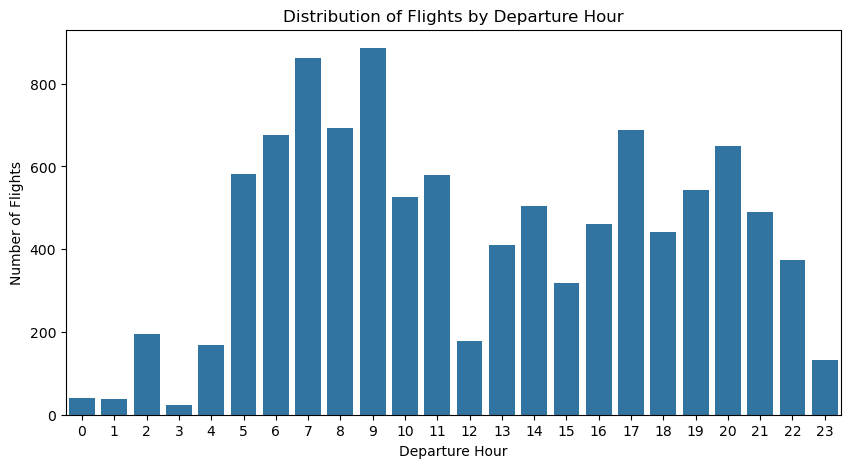

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x='Dep_Hour', data=df)
plt.title('Distribution of Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.show()

##### Conclusion-
###### Dep_Time shows that flight departures are distributed across different hours of the day.

###### The highest number of flights depart around 9 AM and 7 AM, while very early morning hours have relatively fewer flights.

###### There are also a considerable number of flights during the evening, particularly around 5 PM and 8 PM.

###### This indicates that departure time varies considerably and may influence flight prices due to differences in demand and travel patterns.

###### During feature engineering, the departure time can be converted into useful numerical features such as departure hour and minute for model building.

In [30]:
print(df['Arrival_Time'].value_counts().head(20))

Arrival_Time
19:00    412
21:00    360
19:15    333
16:10    154
12:35    122
20:45    112
22:30    111
18:50    110
22:50    104
11:20     95
19:50     94
21:20     88
12:20     87
22:25     77
21:05     72
23:35     71
20:05     69
14:05     68
08:35     66
12:00     63
Name: count, dtype: int64


##### Conclusion-
###### 19:00 has the highest number of flights: 412
###### 21:00 comes next with 360
###### 19:15 has 333
###### Other common arrival times include 16:10, 12:35, 20:45, 22:30
###### There are many different arrival times, so using every exact time as a category would not be very useful.

#### Extracting Arrival Hour

In [31]:
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour

print(df['Arrival_Hour'].value_counts().sort_index())

Arrival_Hour
0      322
1      525
2       79
3       47
4      761
5       66
6       51
7      414
8      468
9      489
10     474
11     297
12     861
13     303
14     294
15     182
16     370
17     191
18     509
19    1554
20     377
21     701
22     646
23     481
Name: count, dtype: int64


###### 7 PM (19:00) has the highest number of arrivals: 1,554 flights.
###### 12 PM (12:00) is next with 861 flights.
###### 4 AM (04:00) has 761 flights.
###### 9 PM (21:00) has 701 flights.
###### 10 PM (22:00) has 646 flights.
###### Very early hours such as 2 AM, 3 AM, 5 AM and 6 AM have comparatively fewer arrivals.
###### Therefore, arrival times are not evenly distributed throughout the day.


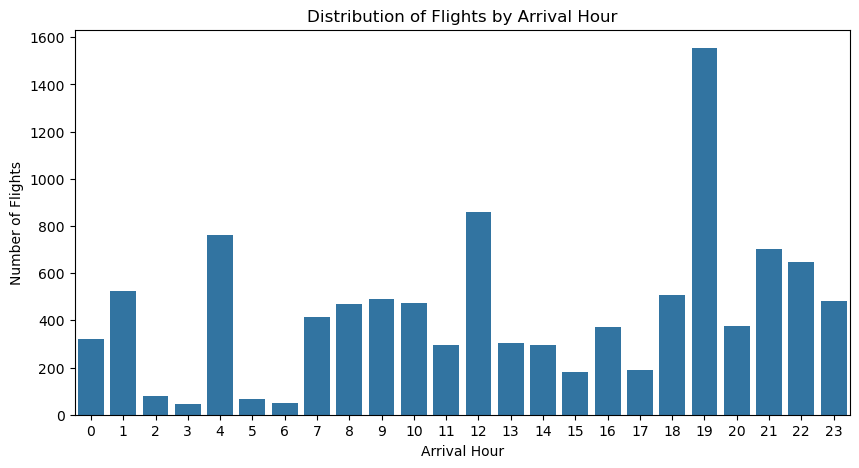

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(x='Arrival_Hour', data=df)

plt.title('Distribution of Flights by Arrival Hour')
plt.xlabel('Arrival Hour')
plt.ylabel('Number of Flights')

plt.show()

###### Arrival_Time shows that flight arrivals are distributed across different hours of the day.
###### The highest number of flights arrive around 7 PM, followed by 12 PM and 4 AM.
###### The distribution is uneven, with some arrival hours having significantly more flights than others.
###### This indicates that arrival time may influence flight prices due to differences in demand, scheduling, and travel patterns.
###### During feature engineering, the arrival time can be converted into useful numerical features such as arrival hour and minute for model building.

#### Duration

In [33]:
print(df['Duration'].value_counts().head(20))

Duration
2h 50m     544
1h 30m     386
2h 45m     335
2h 55m     332
2h 35m     329
3h         260
2h 20m     238
2h 30m     220
2h 40m     156
1h 25m     135
2h 15m     135
2h 25m      98
13h 20m     89
3h 15m      88
7h 30m      86
9h 30m      85
8h 40m      81
13h 30m     80
7h 15m      79
3h 5m       78
Name: count, dtype: int64


##### Converting Duration to minutes

In [34]:
def duration_to_minutes(x):
    hours = 0
    minutes = 0

    if 'h' in x:
        hours = int(x.split('h')[0].strip())

    if 'm' in x:
        minutes = int(x.split('h')[-1].replace('m', '').strip())

    return hours * 60 + minutes


df['Duration_Minutes'] = df['Duration'].apply(duration_to_minutes)

print(df[['Duration', 'Duration_Minutes']].head(10))

  Duration  Duration_Minutes
0   2h 50m               170
1   7h 25m               445
2      19h              1140
3   5h 25m               325
4   4h 45m               285
5   2h 25m               145
6  15h 30m               930
7   21h 5m              1265
8  25h 30m              1530
9   7h 50m               470


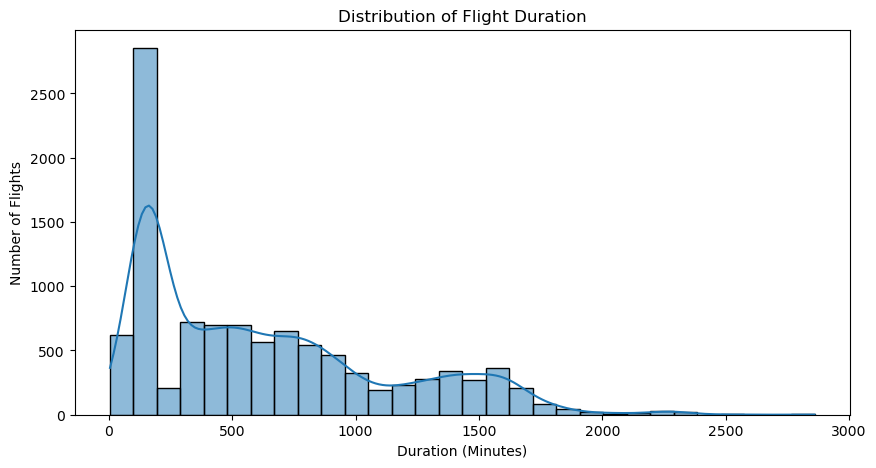

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(df['Duration_Minutes'], bins=30, kde=True)
plt.title('Distribution of Flight Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Flights')

plt.show()

In [36]:
print("Minimum Duration:", df['Duration_Minutes'].min(), "minutes")
print("Maximum Duration:", df['Duration_Minutes'].max(), "minutes")
print("Average Duration:", round(df['Duration_Minutes'].mean(), 2), "minutes")
print("Median Duration:", df['Duration_Minutes'].median(), "minutes")

Minimum Duration: 5 minutes
Maximum Duration: 2860 minutes
Average Duration: 629.78 minutes
Median Duration: 505.0 minutes


##### Conclusion –

###### Duration shows considerable variation in the total travel time of flights.

###### The flight duration ranges from 5 minutes to 2,860 minutes, indicating the presence of both very short and very long journeys.

###### The average duration is approximately 630 minutes, while the median duration is 505 minutes, suggesting that the distribution is right-skewed due to longer-duration flights.

###### Flight duration may have an important relationship with flight price, as longer journeys may involve more stops and higher operating costs.

###### During feature engineering, Duration can be represented as a numerical feature in minutes for model building.

##### Checking Numerical Columns

In [37]:
print(df.select_dtypes(include='number').columns)

Index(['Price', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes'], dtype='object')


##### Correlation Matrix

In [38]:
corr = df[['Price', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes']].corr()
print(corr)

                     Price  Dep_Hour  Arrival_Hour  Duration_Minutes
Price             1.000000  0.005155      0.031023          0.501758
Dep_Hour          0.005155  1.000000     -0.003827         -0.001285
Arrival_Hour      0.031023 -0.003827      1.000000          0.061912
Duration_Minutes  0.501758 -0.001285      0.061912          1.000000


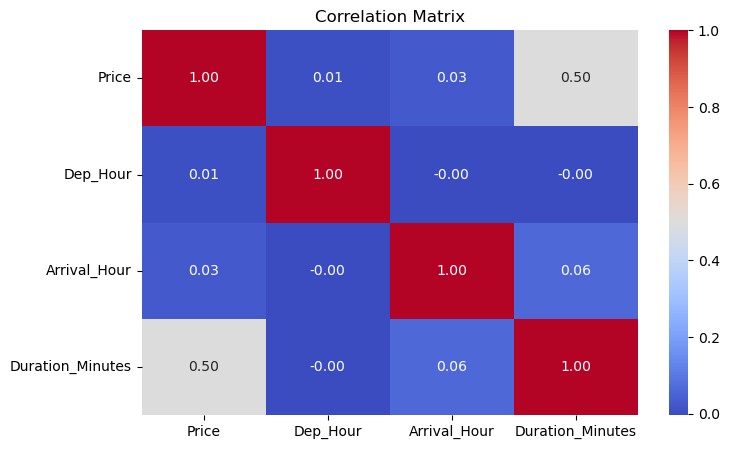

In [39]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [40]:
print(df[['Price', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes']].corr()['Price'])

Price               1.000000
Dep_Hour            0.005155
Arrival_Hour        0.031023
Duration_Minutes    0.501758
Name: Price, dtype: float64


#### Conclusion –

###### The correlation analysis shows that Duration_Minutes has a moderate positive correlation (0.502) with Price, indicating that longer flight durations generally tend to have higher prices.

###### Arrival_Hour has a very weak positive correlation (0.031) with Price, while Dep_Hour has almost no linear correlation (0.005).

###### This suggests that flight duration is more strongly related to price than departure or arrival hour among the numerical variables analyzed.

###### However, correlation measures only linear relationships, so categorical variables such as airline, source, destination, and number of stops may also have an important influence on flight prices.

#### Checking Outliers

In [41]:
num_cols = ['Price', 'Duration_Minutes', 'Dep_Hour', 'Arrival_Hour']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Lower Limit:", lower)
    print("Upper Limit:", upper)
    print("Number of Outliers:", len(outliers))


Price
Lower Limit: -5457.125
Upper Limit: 23025.875
Number of Outliers: 94

Duration_Minutes
Lower Limit: -940.0
Upper Limit: 2020.0
Number of Outliers: 75

Dep_Hour
Lower Limit: -7.0
Upper Limit: 33.0
Number of Outliers: 0

Arrival_Hour
Lower Limit: -8.5
Upper Limit: 35.5
Number of Outliers: 0


###### Some expensive flights can be genuine.
###### Long-duration flights can also be genuine, especially when there are multiple stops.
###### Removing them could cause us to lose meaningful information.
###### so retain the outliers 

##### Outlier Analysis –

###### The IQR method was used to identify potential outliers in the numerical variables.

###### Price has 94 potential outliers, while Duration_Minutes has 75 potential outliers.

###### No outliers were detected in Dep_Hour or Arrival_Hour because their values naturally fall within the calculated IQR limits.

###### The identified outliers in price and duration may represent genuine expensive flights or long journeys, particularly those involving multiple stops.

###### Therefore, these observations will not be removed automatically at this stage. Their impact can be evaluated during preprocessing and model building.

#### Final EDA Summary

##### Final EDA Summary

###### The dataset contains flight-related information such as Airline, Source, Destination, Total Stops, Date of Journey, Departure Time, Arrival Time, Duration, and Price.

###### The Price distribution is right-skewed, with most flight prices concentrated in the lower range and a smaller number of high-priced flights.

###### Airline has an important influence on flight prices, with some airlines generally having higher prices than others.

###### Source and Destination also show differences in flight prices, indicating that the travel route can affect the ticket price.

###### Flights with different numbers of stops show differences in pricing. Generally, flights with more stops can have higher prices because of longer travel durations and route complexity.

###### Additional_Info is highly imbalanced, with No info being the dominant category and several rare categories.

###### Date_of_Journey shows an uneven distribution of flights across the available travel dates, suggesting that travel date may influence demand and pricing.

###### Departure and arrival times are distributed across different hours of the day. Some hours have considerably more flights than others.

###### Duration ranges from 5 minutes to 2,860 minute, with an average of approximately 630 minutes and a median of 505 minutes.The difference between the mean and median indicates a right-skewed distribution.

###### The correlation analysis shows that Duration_Minutes has a moderate positive correlation with Price (0.502), while Dep_Hour and Arrival_Hour have very weak linear correlations with Price.

###### Outlier analysis using the IQR method identified 94 potential outliers in Price and 75 in Duration_Minutes. These observations will not be removed automatically because they may represent genuine expensive flights or long journeys.

### Overall Finding

###### The EDA indicates that flight price is influenced by multiple factors, including airline, route, number of stops, journey date, duration, and timing. Among the numerical variables analyzed,flight duration shows the strongest relationship with price.

###### These findings will guide the next steps of data preprocessing, feature engineering, encoding categorical variables, and model building.


### EDA – Business Insights

The exploratory data analysis provides several important insights into flight fare patterns:

* **Airline:** Flight prices vary considerably across airlines. Premium airlines and business-class services tend to have higher fares, while some airlines offer relatively lower-priced options. This indicates that airline type and service level are important factors in fare prediction.

* **Journey Duration:** Longer-duration flights generally have higher fares because they may involve longer routes, more stops, or greater operational costs. `Duration_Minutes` is also identified as the most influential feature in the final Random Forest model.

* **Number of Stops:** Flight price does not increase in a simple linear manner with the number of stops. Both direct and connecting flights show variation in prices depending on the airline, route, and other factors.

* **Source and Destination:** Fare patterns differ across source and destination cities. Certain routes have higher average prices, suggesting that route characteristics and demand can influence ticket prices.

* **Date and Time:** Flight fares vary across journey dates and departure/arrival times. This indicates that travel timing can contribute to differences in ticket prices.

* **Outliers:** Some flights have unusually high fares or long durations. These observations were retained because they may represent genuine premium flights, business-class services, or longer journeys rather than data errors.

### Overall Business Insight

The analysis shows that flight fares are influenced by a combination of **airline, route, journey duration, number of stops, and travel timing**. These insights can help airlines understand pricing patterns and can help customers estimate fares and plan travel more effectively.


### Preprocessing

### Separating x and y

In [42]:
X = df.drop('Price', axis=1)
y = df['Price']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Train_Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [45]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8369, 13)
X_test: (2093, 13)
y_train: (8369,)
y_test: (2093,)


In [46]:
print(X_train.dtypes)

Airline             object
Date_of_Journey     object
Source              object
Destination         object
Route               object
Dep_Time            object
Arrival_Time        object
Duration            object
Total_Stops         object
Additional_Info     object
Dep_Hour             int32
Arrival_Hour         int32
Duration_Minutes     int64
dtype: object


#### Conversion of Date Of Month

In [47]:
X_train['Date_of_Journey'] = pd.to_datetime(
    X_train['Date_of_Journey'],
    dayfirst=True
)

X_test['Date_of_Journey'] = pd.to_datetime(
    X_test['Date_of_Journey'],
    dayfirst=True
)


#### Extraction of Day and Month

In [48]:
X_train['Journey_Day'] = X_train['Date_of_Journey'].dt.day
X_train['Journey_Month'] = X_train['Date_of_Journey'].dt.month

X_test['Journey_Day'] = X_test['Date_of_Journey'].dt.day
X_test['Journey_Month'] = X_test['Date_of_Journey'].dt.month

In [49]:
X_train.drop('Date_of_Journey', axis=1, inplace=True)
X_test.drop('Date_of_Journey', axis=1, inplace=True)

In [50]:
print(X_train.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Dep_Hour',
       'Arrival_Hour', 'Duration_Minutes', 'Journey_Day', 'Journey_Month'],
      dtype='object')


In [51]:
X_train.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)
X_test.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)

In [52]:
print(X_train.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes',
       'Journey_Day', 'Journey_Month'],
      dtype='object')


In [53]:
print(X_train.columns)


Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes',
       'Journey_Day', 'Journey_Month'],
      dtype='object')


In [54]:
X_train.drop('Duration', axis=1, inplace=True)
X_test.drop('Duration', axis=1, inplace=True)

In [55]:
print(X_train.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes',
       'Journey_Day', 'Journey_Month'],
      dtype='object')


In [56]:
print(X_train['Total_Stops'].value_counts())

Total_Stops
1 stop      4496
non-stop    2767
2 stops     1073
3 stops       33
Name: count, dtype: int64


#### Converting total_stops to numerical

In [57]:
stop_mapping = {
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3
}

X_train['Total_Stops'] = X_train['Total_Stops'].map(stop_mapping)
X_test['Total_Stops'] = X_test['Total_Stops'].map(stop_mapping)

In [58]:
print(X_train['Total_Stops'].value_counts().sort_index())

Total_Stops
0    2767
1    4496
2    1073
3      33
Name: count, dtype: int64


#### Checking Additional_Info

In [59]:
print(X_train['Additional_Info'].value_counts())

Additional_Info
No info                         6566
In-flight meal not included     1530
No check-in baggage included     244
1 Long layover                    15
Change airports                    5
Business class                     4
No Info                            2
Red-eye flight                     1
2 Long layover                     1
1 Short layover                    1
Name: count, dtype: int64


###### Additional_Info is highly imbalanced:

###### No info → 6,566 records
###### In-flight meal not included → 1,530
###### No check-in baggage included → 244
###### Remaining categories → very few records

In [60]:
X_train.drop('Additional_Info', axis=1, inplace=True)
X_test.drop('Additional_Info', axis=1, inplace=True)

In [61]:
print(X_train.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Dep_Hour',
       'Arrival_Hour', 'Duration_Minutes', 'Journey_Day', 'Journey_Month'],
      dtype='object')


In [62]:
print(X_train['Airline'].value_counts())

Airline
Jet Airways                          2978
IndiGo                               1621
Air India                            1345
Multiple carriers                     937
SpiceJet                              651
Vistara                               399
Air Asia                              259
GoAir                                 159
Multiple carriers Premium economy      10
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


### Encoding Airline

In [63]:
X_train = pd.get_dummies(X_train, columns=['Airline'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Airline'], drop_first=True)

In [64]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [65]:
print(X_train.columns)
print("\nShape:", X_train.shape)

Index(['Source', 'Destination', 'Route', 'Total_Stops', 'Dep_Hour',
       'Arrival_Hour', 'Duration_Minutes', 'Journey_Day', 'Journey_Month',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy'],
      dtype='object')

Shape: (8369, 20)


In [66]:
print(X_train['Source'].value_counts())

Source
Delhi       3465
Kolkata     2300
Banglore    1731
Mumbai       571
Chennai      302
Name: count, dtype: int64


### Encoding Source

In [67]:
X_train = pd.get_dummies(X_train, columns=['Source'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Source'], drop_first=True)

In [68]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [69]:
print(X_train.columns)
print("\nShape:", X_train.shape)

Index(['Destination', 'Route', 'Total_Stops', 'Dep_Hour', 'Arrival_Hour',
       'Duration_Minutes', 'Journey_Day', 'Journey_Month', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai'],
      dtype='object')

Shape: (8369, 23)


In [70]:
print(X_train['Destination'].value_counts())

Destination
Cochin       3465
Banglore     2300
Delhi         996
New Delhi     735
Hyderabad     571
Kolkata       302
Name: count, dtype: int64


### Encoding Destination

In [71]:
X_train = pd.get_dummies(X_train, columns=['Destination'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Destination'], drop_first=True)

In [72]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [73]:
print(X_train.columns)
print("\nShape:", X_train.shape)

Index(['Route', 'Total_Stops', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes',
       'Journey_Day', 'Journey_Month', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')

Shape: (8369, 27)


In [74]:
print("Number of unique routes:", X_train['Route'].nunique())

print("\nTop 10 routes:")
print(X_train['Route'].value_counts().head(10))

Number of unique routes: 126

Top 10 routes:
Route
DEL → BOM → COK    1878
BLR → DEL          1217
CCU → BOM → BLR     790
CCU → BLR           579
BOM → HYD           506
CCU → DEL → BLR     462
BLR → BOM → DEL     324
MAA → CCU           302
DEL → HYD → COK     260
DEL → BLR → COK     191
Name: count, dtype: int64


In [75]:
X_train['Route_Count'] = X_train['Route'].apply(lambda x: len(x.split('→')))
X_test['Route_Count'] = X_test['Route'].apply(lambda x: len(x.split('→')))

In [76]:
print(X_train[['Route', 'Route_Count']].head())

                Route  Route_Count
6727        BOM → HYD            2
6322  DEL → BOM → COK            3
6874  DEL → BOM → COK            3
3493  CCU → MAA → BLR            3
611   DEL → BOM → COK            3


In [77]:
X_train.drop('Route', axis=1, inplace=True)
X_test.drop('Route', axis=1, inplace=True)

In [78]:
print(X_train.shape)
print(X_train.columns)

(8369, 27)
Index(['Total_Stops', 'Dep_Hour', 'Arrival_Hour', 'Duration_Minutes',
       'Journey_Day', 'Journey_Month', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi', 'Route_Count'],
      dtype='object')


In [79]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

Missing values in X_train:
0

Missing values in X_test:
1


In [80]:
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Total_Stops    1
dtype: int64


In [81]:
print(X_test[X_test['Total_Stops'].isnull()])

      Total_Stops  Dep_Hour  Arrival_Hour  Duration_Minutes  Journey_Day  \
9182          NaN         5            11              1770            1   

      Journey_Month  Airline_Air India  Airline_GoAir  Airline_IndiGo  \
9182              3               True          False           False   

      Airline_Jet Airways  ...  Source_Chennai  Source_Delhi  Source_Kolkata  \
9182                False  ...           False         False           False   

      Source_Mumbai  Destination_Cochin  Destination_Delhi  \
9182          False               False              False   

      Destination_Hyderabad  Destination_Kolkata  Destination_New Delhi  \
9182                  False                False                   True   

      Route_Count  
9182            6  

[1 rows x 27 columns]


In [82]:
print(df.loc[9182, ['Route', 'Total_Stops']])

Route          BLR → CCU → BBI → HYD → VGA → DEL
Total_Stops                              4 stops
Name: 9182, dtype: object


In [83]:
X_train['Total_Stops'] = df.loc[X_train.index, 'Total_Stops'].map({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

X_test['Total_Stops'] = df.loc[X_test.index, 'Total_Stops'].map({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

In [84]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [85]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nData types:")
print(X_train.dtypes)

X_train shape: (8369, 27)
X_test shape: (2093, 27)

Data types:
Total_Stops                                  int64
Dep_Hour                                     int32
Arrival_Hour                                 int32
Duration_Minutes                             int64
Journey_Day                                  int32
Journey_Month                                int32
Airline_Air India                             bool
Airline_GoAir                                 bool
Airline_IndiGo                                bool
Airline_Jet Airways                           bool
Airline_Jet Airways Business                  bool
Airline_Multiple carriers                     bool
Airline_Multiple carriers Premium economy     bool
Airline_SpiceJet                              bool
Airline_Trujet                                bool
Airline_Vistara                               bool
Airline_Vistara Premium economy               bool
Source_Chennai                                bool
Source_Delhi      

In [86]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nPrice statistics:")
print(y_train.describe())

y_train shape: (8369,)
y_test shape: (2093,)

Price statistics:
count     8369.000000
mean      9051.693512
std       4639.066347
min       1759.000000
25%       5228.000000
50%       8309.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64


In [87]:
print([var for var in dir() if 'train' in var.lower() or 'test' in var.lower()])

['X_test', 'X_train', 'train_test_split', 'y_test', 'y_train']


In [88]:
print(df.dtypes)

Airline             object
Date_of_Journey     object
Source              object
Destination         object
Route               object
Dep_Time            object
Arrival_Time        object
Duration            object
Total_Stops         object
Additional_Info     object
Price                int64
Dep_Hour             int32
Arrival_Hour         int32
Duration_Minutes     int64
dtype: object


In [89]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Fit on training data and transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (8369, 27)
X_test_processed shape: (2093, 27)


### Model Building

## Prepare the processed data

In [90]:
# Converting the processed training and testing data into numerical arrays
X_train_model = np.asarray(X_train_processed, dtype=float)
X_test_model = np.asarray(X_test_processed, dtype=float)

print("Training data shape:", X_train_model.shape)
print("Testing data shape:", X_test_model.shape)

Training data shape: (8369, 27)
Testing data shape: (2093, 27)


In [91]:
# importing evaluation matrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [92]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

    return [model_name, mae, mse, rmse, r2]

## Linear Regression

In [93]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_model, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_model)

# Evaluate the model
lr_result = evaluate_model("Linear Regression", y_test, lr_pred)


Linear Regression
Mean Absolute Error: 1999.99
Mean Squared Error: 8677237.88
Root Mean Squared Error: 2945.72
R² Score: 0.5838


## Decision Tree

In [94]:
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train_model, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test_model)

# Evaluate the model
dt_result = evaluate_model("Decision Tree", y_test, dt_pred)


Decision Tree
Mean Absolute Error: 1448.46
Mean Squared Error: 6216662.24
Root Mean Squared Error: 2493.32
R² Score: 0.7018


## Random Forest

In [95]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

# Train the model
rf_model.fit(X_train_model, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test_model)

# Evaluate the model
rf_result = evaluate_model("Random Forest", y_test, rf_pred)


Random Forest
Mean Absolute Error: 1213.79
Mean Squared Error: 3958138.57
Root Mean Squared Error: 1989.51
R² Score: 0.8102


## Gradient Boosting

In [96]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model
gb_model.fit(X_train_model, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test_model)

# Evaluate the model
gb_result = evaluate_model("Gradient Boosting", y_test, gb_pred)


Gradient Boosting
Mean Absolute Error: 1546.57
Mean Squared Error: 5189802.46
Root Mean Squared Error: 2278.11
R² Score: 0.7511


## KNN

In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# Scaling the features for KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

# Creating the KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Training the model
knn_model.fit(X_train_scaled, y_train)

# Making predictions
knn_pred = knn_model.predict(X_test_scaled)

# Evaluating the model
knn_result = evaluate_model("KNN", y_test, knn_pred)


KNN
Mean Absolute Error: 1411.74
Mean Squared Error: 4815193.78
Root Mean Squared Error: 2194.35
R² Score: 0.7691


 KNN is a distance-based algorithm, so feature scaling is important. Our dataset contains features with different numerical ranges. Without scaling, features with larger values may have more influence on the distance calculation.

Therefore, StandardScaler is used to bring the features to a comparable scale. This allows KNN to calculate distances more fairly and make better predictions.

Note: Scaling is applied only to KNN because it is particularly important for distance-based algorithms.

### Summary KNN

KNN was also evaluated as a regression model. Since KNN uses distance
calculations, feature scaling was applied specifically to this model using
StandardScaler. The scaled training and testing data were then used to build
the KNN model and evaluate its performance.

### Summary of Model Building

Five regression models were developed to predict flight prices: Linear
Regression, Decision Tree, Random Forest, Gradient Boosting, and KNN.

Each model was trained using the training data and evaluated on the test data.
MAE, MSE, RMSE, and R² Score were used to compare their prediction performance.

## Comparison of All Five Models
The five regression models are compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Lower values of MAE, MSE, and RMSE indicate lower prediction errors, while a higher R² Score indicates better model performance.

Therefore, Random Forest was selected for further improvement through
hyperparameter tuning.

In [98]:
# Comparing all five regression models

results_df = pd.DataFrame(
    [
        lr_result,
        dt_result,
        rf_result,
        gb_result,
        knn_result
    ],
    columns=["Model", "MAE", "MSE", "RMSE", "R² Score"]
)

# Sort based on R² Score
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R² Score
0,Random Forest,1213.793922,3.958139e+06,1989.507117,0.810164
1,KNN,1411.738079,4.815194e+06,2194.354980,0.769059
2,Gradient Boosting,1546.566785,5.189802e+06,2278.113795,0.751092
3,Decision Tree,1448.462414,6.216662e+06,2493.323533,0.701843
4,Linear Regression,1999.994010,8.677238e+06,2945.715172,0.583831


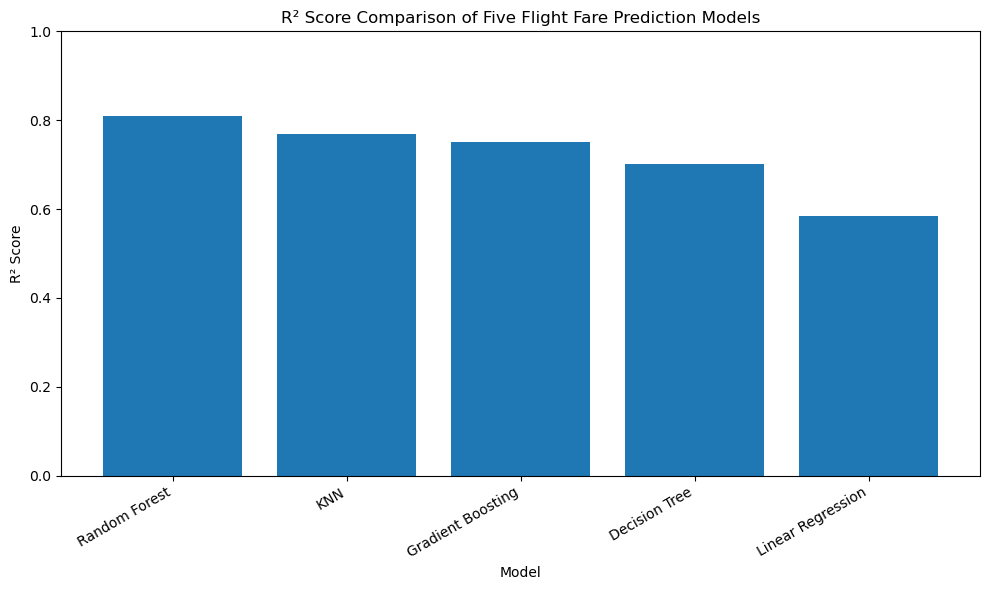

In [99]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R² Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison of Five Flight Fare Prediction Models")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Model Comparison Conclusion
Among the five models, Random Forest performed the best with an R² Score of 0.8102, the lowest MAE of 1213.79, and the lowest RMSE of 1989.51. Therefore, Random Forest was selected as the best initial model for flight fare prediction. Hyperparameter tuning was then performed to further improve its performance.

## HyperParameterTuning

## Hyperparameter Tuning – Random Forest
Random Forest performed better than the other models in the initial comparison. To improve its performance further, hyperparameter tuning is performed using RandomizedSearchCV. Different combinations of parameters are tested using cross-validation, and the best combination is selected based on the R² score.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Creating Random Forest model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

# Hyperparameter tuning
rf_tuning = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

# Training the model
rf_tuning.fit(X_train_model, y_train)

# Displaying the best parameters
print("Best Parameters:")
print(rf_tuning.best_params_)

print("\nBest Cross-Validation R² Score:")
print(round(rf_tuning.best_score_, 4))

## Evaluation of Tuned model

In [ ]:
# Using the best model
tuned_rf_model = rf_tuning.best_estimator_

# Making predictions
tuned_rf_pred = tuned_rf_model.predict(X_test_model)

# Evaluating the tuned model
tuned_rf_result = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred
)

 ### Comparison of Original and Tuned Random Forest

The original Random Forest model was further improved using hyperparameter tuning.
The tuned model achieved a lower MAE, MSE, and RMSE, while the R² Score increased
from 0.8102 to 0.8280. This shows that hyperparameter tuning improved the model's
prediction performance.

In [ ]:
# Comparing Original and Tuned Random Forest

rf_comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Original Random Forest": [
        rf_result[1],
        rf_result[2],
        rf_result[3],
        rf_result[4]
    ],
    "Tuned Random Forest": [
        tuned_rf_result[1],
        tuned_rf_result[2],
        tuned_rf_result[3],
        tuned_rf_result[4]
    ]
})

rf_comparison

  The tuned Random Forest model performed better than the original Random Forest
model. The R² Score improved from 0.8102 to 0.8280, while the error metrics
decreased. Therefore, the tuned Random Forest model is selected as the final model.

### Feature Importance Analysis

Feature importance is used to understand which features contribute most to the
flight fare prediction. The importance values are obtained from the tuned
Random Forest model.

In [ ]:
# Getting feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Getting feature importance from the tuned Random Forest
feature_importance = tuned_rf_model.feature_importances_

# Creating a DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sorting by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
importance_df.head(15)

In [ ]:
import matplotlib.pyplot as plt

# Display top 15 important features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

## Feature Importance Interpretation
The feature importance analysis shows that Duration_Minutes is the most important feature for predicting flight prices, with an importance of about 0.49. Journey_Day is the second most important feature, followed by Jet Airways Business and Jet Airways. Journey Month, arrival time, and departure time also contribute to the prediction.

This indicates that flight duration, journey date, airline, and timing-related features have a noticeable influence on the predicted flight far

### Actual vs Predicted Price

The actual and predicted flight prices are compared to understand how well the
final tuned Random Forest model is predicting flight fares. A scatter plot is
used to visualize the relationship between the actual and predicted values.

In [ ]:
# Actual vs Predicted Flight Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, tuned_rf_pred, alpha=0.5)

# Reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")
plt.tight_layout()
plt.show()

## Interpretation
The scatter plot shows the relationship between the actual flight prices and the prices predicted by the tuned Random Forest model. Points closer to the diagonal reference line indicate more accurate predictions. The model is able to capture the general pattern of flight fares, although some differences between actual and predicted prices are present.

## Final Model validation

### Prediction Error Analysis

Prediction errors were calculated by comparing the actual prices with the
predicted prices from the tuned Random Forest model. The average prediction
error was close to zero, although some flights showed larger differences.

These larger errors may occur because flight prices can vary considerably
depending on different flight characteristics.

In [ ]:
# Calculating prediction errors

prediction_errors = y_test - tuned_rf_pred

error_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": tuned_rf_pred,
    "Prediction Error": prediction_errors
})

error_df.head(10)

In [ ]:
# Average Error
print("Average Prediction Error:", round(prediction_errors.mean(), 2))
print("Minimum Error:", round(prediction_errors.min(), 2))
print("Maximum Error:", round(prediction_errors.max(), 2))

## Final Model Selection

Based on the model comparison and hyperparameter tuning results, the Tuned
Random Forest model is selected as the final model. It achieved the lowest
error values and the highest R² Score among the evaluated models.

The Tuned Random Forest achieved an MAE of 1177.72, RMSE of 1893.62, and
an R² Score of 0.8280. Therefore, it provides the best overall performance
for predicting flight fares.

## Challenges Faced

### 1. Categorical Features
The dataset contained categorical features such as Airline, Source, and
Destination. One-hot encoding was used to convert these values into numerical
features.

### 2. Date and Time Features
Date and time columns were not directly suitable for model building.
Therefore, journey day, journey month, departure hour, and arrival hour were
extracted from the original columns.

### 3. Different Feature Scales
KNN is a distance-based algorithm, so StandardScaler was used specifically for
KNN to bring the features to a comparable scale.

### 4. Model Selection
Different regression models produced different results. Therefore, five
models were trained and compared using MAE, MSE, RMSE, and R² Score to select
the best-performing model.

### 5. Model Improvement
The initial Random Forest model was further improved using RandomizedSearchCV.
Hyperparameter tuning helped improve the final prediction performance.

## Project Conclusion

In this project, different machine learning regression models were developed
to predict flight fares. The data was cleaned and prepared by handling
categorical and numerical features before model building.

Five models were evaluated: Linear Regression, Decision Tree, Random Forest,
Gradient Boosting, and KNN. Among the initial models, Random Forest performed
the best with an R² Score of 0.8102.

Hyperparameter tuning was then applied to the Random Forest model to improve
its performance. The tuned Random Forest achieved an R² Score of 0.8280, with
an MAE of 1177.72 and an RMSE of 1893.62. The feature importance analysis also
showed that Duration_Minutes was the most influential feature for predicting
flight fares.

Based on the evaluation results, the Tuned Random Forest model was selected
as the final model for flight fare prediction.

### saving the final .pkl model

In [ ]:
import joblib

# Save the preprocessing object
joblib.dump(preprocessor, "flight_fare_preprocessor.pkl")

# Save the final tuned Random Forest model
joblib.dump(tuned_rf_model, "flight_fare_model.pkl")

print("Final model and preprocessor saved successfully.")

In [ ]:
# Loading the saved files to verify
loaded_preprocessor = joblib.load("flight_fare_preprocessor.pkl")
loaded_model = joblib.load("flight_fare_model.pkl")

print("Model and preprocessor loaded successfully.")